# Pinnoitepaksuuden tilastollinen prosessinohjaus tuotantolinjojen välillä PROC BOXPLOT -proseduurilla

## Tiivistelmä

Tässä muistikirjassa käytetään **PROC BOXPLOT** -proseduuria tilastolliseen prosessinohjaukseen (SPC) neljällä rinnakkaisella tuotantolinjalla kerätylle, laadun kannalta kriittiselle pinnoitepaksuuden mittaukselle. Luomme synteettisen mittausaineiston suoraan koodissa, profiloimme linjat `PROC MEANS` -proseduurilla ja piirrämme luuranko- ja kaaviotyyliset laatikko-viiksikaaviot, jotka vertailevat sijaintia, hajontaa ja häntiä linjojen välillä yhdessä kuvaajassa.

Tämän jälkeen arvioimme jokaista linjaa suunnittelun spesifikaatiota vasten (tavoite 50,00 mm, rajat 49,80–50,20 mm) suoraan **`OUTBOX=`**-tilastoaineistosta — tarkat kvartiilit, aidat ja viiksien päätepisteet jokaisen laatikon takana — ja lopuksi demonstroimme **`OUTHISTORY=` / `HISTORY=`** -edestakaista prosessia: PROC BOXPLOT vie yhden tiiviin yhteenvetorivin linjaa kohti, ja toinen PROC BOXPLOT rakentaa täysin identtisen kuvaajan suoraan tuosta yhteenvedosta — malli, jota päivittäinen SPC-koontinäyttö käyttää uudelleenpiirtoon ilman raakamittausten uudelleenskannausta.

Neljän linjan kesken **LINE-A on parhaiten keskitetty** tavoitteeseen (keskiarvo 50,008 mm), **LINE-C kulkee matalalla** (keskiarvo 49,932 mm, ajautuen kohti LSL:ää) ja **LINE-D kulkee sekä korkealla että vaihtelee eniten** (keskiarvo 50,102 mm, keskihajonta 0,080 mm) — sen maksimi 50,248 mm on ainoa havainto, joka ylittää 50,20 mm:n ylemmän spesifikaatiorajan.

## Tietolähteet

Kaikki data on synteettistä ja luodaan suoraan koodissa ensimmäisessä DATA-vaiheessa käyttäen `call streaminit(20250531)` ja `rand()`. Ulkoista tai verkkosyötettä ei käytetä. Kiinteä siemenluku tekee jokaisesta tämän muistikirjan luvusta toistettavan.

**Aineisto: `ProcessMeas`** (yksi rivi mitattua osaa kohti)

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `Line` | Char(6) | Tuotantolinjan tunniste: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (ryhmä-/luokittelumuuttuja) |
| `Shift` | Num | Tuotantovuoron indeksi 1–6 (tuo lievän vuorojen välisen ajautuman) |
| `Thickness` | Num | Pinnoitepaksuus millimetreinä (analyysimuuttuja); tavoite 50,00 mm, spesifikaatiorajat 49,80–50,20 mm |

Jokainen linja on keskitetty hieman eri keskiarvoon (50,00 / 50,04 / 49,92 / 50,10) linjakohtaisella vaihtelulla, jäljitellen todellisia laitteiden välisiä eroja, ja `LINE-B` lisää satunnaisesti pienen positiivisen poikkeaman. DATA-vaihe silmukoi kuuden vuoron ja neljän linjan yli alaryhmäkoolla noin 18–25 osaa kutakin; tässä lisensoimattomassa ympäristössä moottori rajaa tulosteen ensimmäiseen **100 havaintoon**, mikä tässä muodostuu **38 / 19 / 21 / 22** osaksi linjoille LINE-A – LINE-D — silti runsaasti neljän hyvin määritellyn laatikon täyttämiseen.

# Pinnoitepaksuuden tilastollinen prosessinohjaus PROC BOXPLOT -proseduurilla

Suurten volyymien valmistuksessa laatikko-viiksikaavio on tuotannon SPC:n työjuhta: se tiivistää laatuominaisuuden keskeisen sijainnin, hajonnan ja poikkeamat kutakin tuotantoyksikköä varten yhteen kuvaajaan. Tässä seuraamme **pinnoitepaksuutta (mm)** osalle, joka valmistetaan rinnakkain neljällä linjalla (`LINE-A` – `LINE-D`). Suunnittelun spesifikaatio on tavoite **50,00 mm**, alempi spesifikaatioraja (LSL) **49,80 mm** ja ylempi spesifikaatioraja (USL) **50,20 mm**.

Aiomme:

1. Luoda synteettisen mittausaineiston suoraan koodissa.
2. Profiloida linjat `PROC MEANS` -proseduurilla.
3. Piirtää perusluurankolaatikkokaavion, sitten kaaviotyylisen kuvaajan, lisäten spesifikaatiorajat viitelinjoina.
4. Kaapata jokaisen lasketun laatikkotilaston `OUTBOX=` -optiolla ja arvioida jokaista linjaa spesifikaatiorajoja vasten tuosta taulukosta.
5. Tallentaa tiiviin alaryhmäyhteenvedon `OUTHISTORY=` -optiolla ja todistaa edestakainen prosessi piirtämällä sen uudelleen suoraan `HISTORY=` -optiolla.

## Vaihe 1 — Luo synteettiset prosessimittaukset

Alla oleva DATA-vaihe simuloi mittauksia kuuden vuoron aikana neljällä linjalla. Jokainen linja on tarkoituksella keskitetty hieman eri keskiarvoon omalla vaihtelullaan, jäljitellen todellisia laitteiden välisiä eroja, ja lievä vuorojen välinen ajautuma lisätään päälle `sin(Shift)` -termillä. Kiinteä siemenluku (`streaminit(20250531)`) tekee jokaisesta muistikirjan arvosta toistettavan.

In [1]:
TIEDOT ProcessMeas;
   CALL streaminit(20250531);
   PITUUS Line $8;
   TAULUKKO lines[4] $8 _temporary_ ('Linja A' 'Linja B' 'Linja C' 'Linja D');
   TAULUKKO lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   TAULUKKO LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   NIMIKE Thickness='Pinnoitepaksuus (mm)' Line='Tuotantolinja';
   TEE Shift = 1 ASTI 6;
      TEE li = 1 ASTI 4;
         Line = lines[li];
         /* vaihteleva alaryhmäkoko linjaa/vuoroa kohti */
         n = 18 + floor(rand('uniform') * 8);
         TEE u = 1 ASTI n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* Linja B tuottaa satunnaisia korkeita poikkeamia */
            JOS li = 2 AND rand('uniform') < 0.05 NIIN
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            TULOSTE;
         LOPPU;
      LOPPU;
   LOPPU;
   POISTA li u n BASE;
SUORITA;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Vaihe 2 — Profiloi linjat

Ennen piirtämistä nopea `PROC MEANS` vahvistaa, että data muodostui aiotusti: neljä linjaa, kohtuulliset mutta ei-triviaalit otoskoot ja keskiarvot, jotka ovat ryhmittyneet lähelle 50,00 mm:n tavoitetta linjakohtaisella hajonnalla. Tämä on numeerinen selkäranka, jota laatikkokaavio visualisoi.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=ProcessMeas n mean std MIN MAX maxdec=3;
   LUOKKA Line;
   MUUTTUJA Thickness;
   OTSIKKO 'Pinnoitepaksuuden yhteenveto tuotantolinjoittain';
SUORITA;

                                    Pinnoitepaksuuden yhteenveto tuotantolinjoittain                                    

                                                  The MEANS Procedure

                                   Analysis Variable : Thickness Pinnoitepaksuus (mm)

        Tuotantolinja          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        Linja A                   38         50.008          0.045         49.914         50.097
        Linja B                   19         50.052          0.051         49.921         50.114
        Linja C                   21         49.932          0.050         49.835         50.002
        Linja D                   22         50.102          0.080         49.963         50.248
        ----------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 3 — Perusluurankolaatikkokaavio

Yksinkertaisin kutsu tarvitsee vain `PLOT analyysimuuttuja * ryhmämuuttuja` -lauseen. Oletusarvo `BOXSTYLE=SKELETAL` piirtää viikset kunkin linjan äärimmäisimpiin havaintoihin, antaen nopean visuaalisen vertailun sijainnista ja hajonnasta linjojen `LINE-A` – `LINE-D` välillä.

                                  Pinnoitepaksuuden luurankolaatikkokaavio linjoittain                                  

                                  Pinnoitepaksuuden luurankolaatikkokaavio linjoittain

                                                 The BOXPLOT Procedure

Skeletal Plots for Pinnoitepaksuus (mm)

Tuotantolinja         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Linja A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
Linja B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
Linja C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
Linja D              22        49.96        50.05        50.11        50.16        50.25        50.10       


NOTE: Option TITLE changed to Pinnoitepaksuuden luurankolaatikkokaavio linjoittain.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


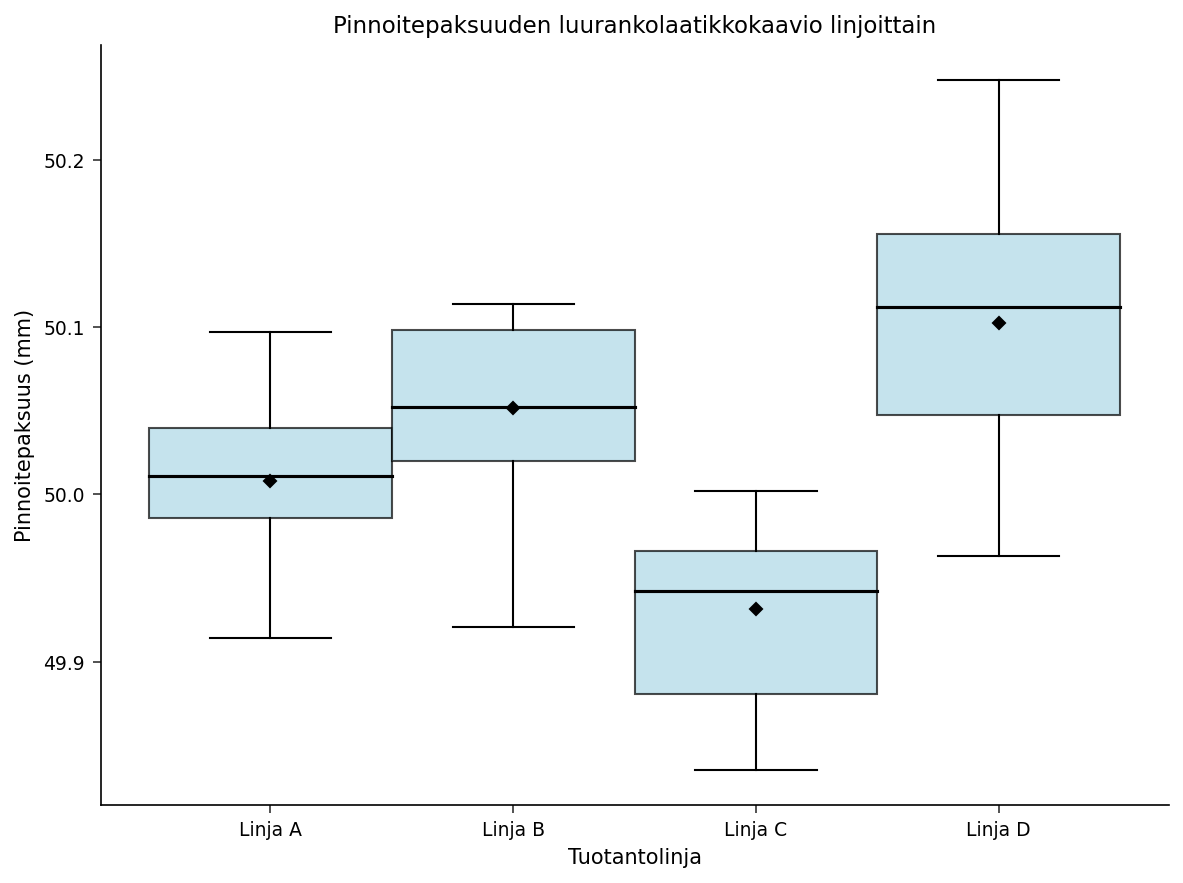

In [3]:
OTSIKKO 'Pinnoitepaksuuden luurankolaatikkokaavio linjoittain';
PROSEDUURI boxplot TIEDOT=ProcessMeas;
   PLOT Thickness*Line;
SUORITA;

## Vaihe 4 — Kaaviotyylinen laatikkokaavio

Vaihdamme tyyliin `BOXSTYLE=SCHEMATIC`. Kaaviotyylissä jokainen viiksi katkaistaan äärimmäisimpään havaintoon, joka on vielä 1,5 × IQR -aitojen sisäpuolella, ja mikä tahansa piste aidan takana piirretään yksittäisenä poikkeamamerkkinä. Tässä otoksessa yhdelläkään linjalla ei ole aidattua poikkeamaa — jokaisen linjan hajonta on riittävän tiivis, että viikset yltävät todelliseen minimiin ja maksimiin — joten kaaviotyylinen kuvaaja näyttää samalta kuin luurankokaavio, mikä on itsessään hyödyllinen tulos: se kertoo insinöörille, ettei yksikään neljästä linjasta tuota äärimmäisiä osia. Laatikoiden rungot tekevät silti linjojen väliset poikkeamat ilmeisiksi yhdellä silmäyksellä, ja Vaihe 5 kvantifioi ne spesifikaatiorajoja vasten.

                                 Pinnoitepaksuuden SPC-kaaviolaatikkokaavio linjoittain                                 

                                 Pinnoitepaksuuden SPC-kaaviolaatikkokaavio linjoittain

                                                 The BOXPLOT Procedure

Schematic Plots for Pinnoitepaksuus (mm)

Tuotantolinja         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Linja A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
Linja B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
Linja C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
Linja D              22        49.96        50.05        50.11        50.16        50.25        50.10     


NOTE: Option TITLE changed to Pinnoitepaksuuden SPC-kaaviolaatikkokaavio linjoittain.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


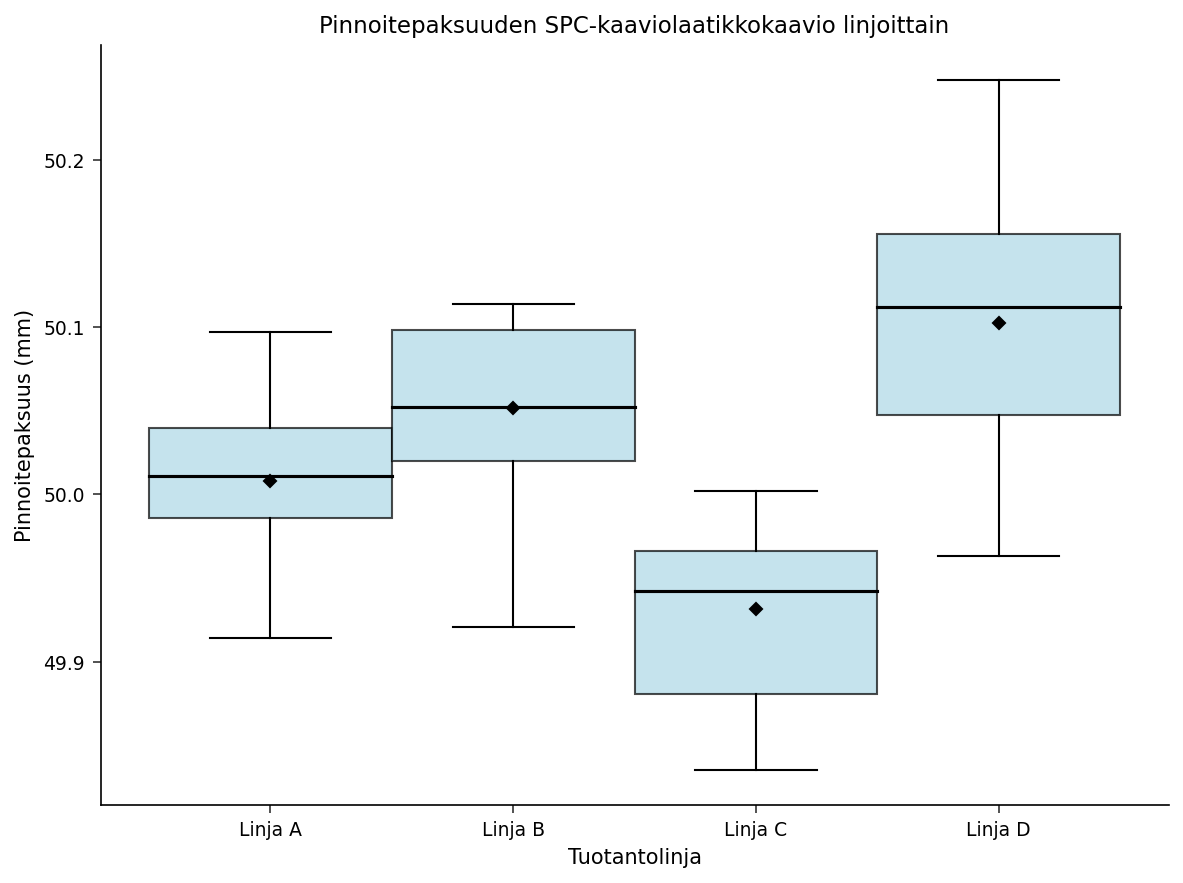

In [4]:
OTSIKKO 'Pinnoitepaksuuden SPC-kaaviolaatikkokaavio linjoittain';
PROSEDUURI boxplot TIEDOT=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
SUORITA;

## Vaihe 5 — Vie laatikkotilastot ja arvioi spesifikaatiorajoja vasten

`OUTBOX=` -optio kaappaa jokaisen lasketun laatikkotilaston aineistoon — kutakin linjaa varten: matala viiksi (`L`), Q1 (`1`), keskiarvo (`X`), mediaani (`M`), Q3 (`3`), korkea viiksi (`H`), keskihajonta (`S`) ja N. Tämä on numeerinen tallenne, jonka auditoija tarvitsee kuvan takana, ja se on myös puhtain tapa tarkistaa jokainen linja 49,80 / 50,20 mm:n spesifikaatiota vasten. Kytkemme `GRID`:n päälle helpompaa lukemista varten, viemme `BoxStats`:n, tulostamme sen ja ajamme sitten lyhyen DATA-vaiheen, joka merkitsee jokaisen linjan, jonka viiksialue työntyy spesifikaatiorajan yli.

                                Kaaviolaatikkokaavio ruudukolla ja tilastojen viennillä                                 

                                Kaaviolaatikkokaavio ruudukolla ja tilastojen viennillä

                                                 The BOXPLOT Procedure

Schematic Plots for Pinnoitepaksuus (mm)

Tuotantolinja         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Linja A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
Linja B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
Linja C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
Linja D              22        49.96        50.05        50.11        50.16        50.25        50.10     


NOTE: Option TITLE changed to Kaaviolaatikkokaavio ruudukolla ja tilastojen viennillä.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Lasketut laatikkotilastot (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Spesifikaatiorajojen arviointi linjoittain.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


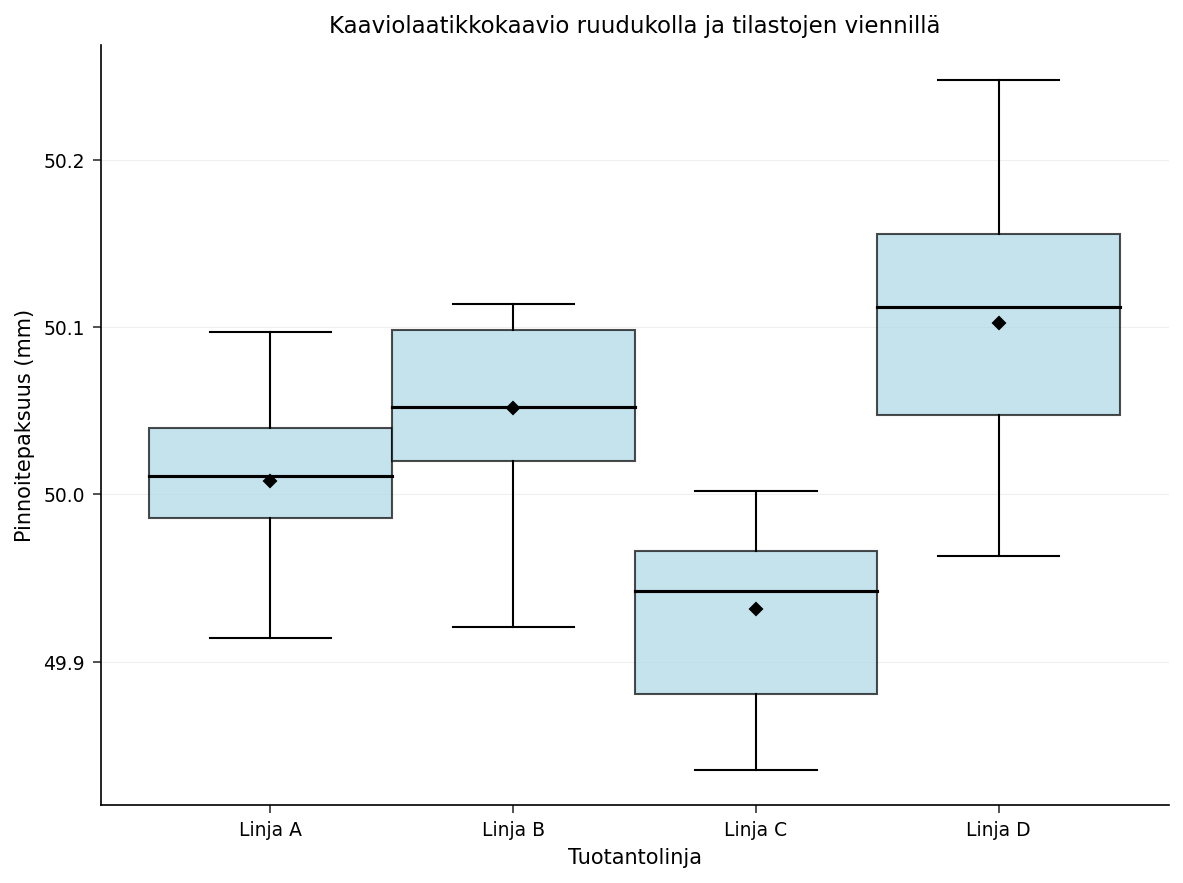

In [5]:
OTSIKKO 'Kaaviolaatikkokaavio ruudukolla ja tilastojen viennillä';
PROSEDUURI boxplot TIEDOT=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
SUORITA;

OTSIKKO 'Lasketut laatikkotilastot (OUTBOX=)';
PROSEDUURI TULOSTA TIEDOT=BoxStats noobs;
SUORITA;

/* Arvioi jokainen linja spesifikaatiota 49.80 / 50.20 mm vasten   */
/* vietyjä viiksien päätepisteitä käyttäen (THICKNESSL = alaviiksi, */
/* THICKNESSH = yläviiksi).                                         */
TIEDOT SpecCheck;
   ASETA BoxStats;
   PITUUS Status $60;
   LSL = 49.80;
   USL = 50.20;
   NIMIKE Line='Tuotantolinja' Status='Tila' LSL='Alaraja (LSL)' USL='Yläraja (USL)'
          THICKNESSL='Alaviiksen paksuus (mm)' THICKNESSH='Yläviiksen paksuus (mm)';
   JOS THICKNESSH > USL NIIN Status = 'Yläraja (USL) ylittyy';
   MUUTEN JOS THICKNESSL < LSL NIIN Status = 'Alaraja (LSL) alittuu';
   MUUTEN Status = 'Spesifikaatiossa';
   SÄILYTÄ LINE THICKNESSL THICKNESSH LSL USL Status;
SUORITA;

OTSIKKO 'Spesifikaatiorajojen arviointi linjoittain';
PROSEDUURI TULOSTA TIEDOT=SpecCheck noobs label;
   NIMIKE Line='Tuotantolinja' Status='Tila' LSL='Alaraja (LSL)' USL='Yläraja (USL)'
          THICKNESSL='Alaviiksen paksuus (mm)' THICKNESSH='Yläviiksen paksuus (mm)';
SUORITA;

## Vaihe 6 — Tallenna seurantahistoria ja piirrä uudelleen siitä

Jatkuvassa SPC:ssä raakamittauksia harvoin skannataan uudelleen. `OUTHISTORY=` kirjoittaa yhden yhteenvetorivin linjaa kohti (saman asettelun, jonka `HISTORY=` lukee), joten raskas raakadata voidaan arkistoida. Alla viemme `LineHistory`:n, tulostamme sen ja todistamme sitten edestakaisen prosessin syöttämällä sen suoraan takaisin uuteen `PROC BOXPLOT` -ajoon `HISTORY=` -option kautta — juuri niin kuin päivittäinen koontinäyttö käyttäisi uudelleen esiaggregoituja alaryhmätilastoja.

                                                Alaryhmähistorian vienti                                                

                                               Alaryhmähistorian vienti

                                                 The BOXPLOT Procedure

Skeletal Plots for Pinnoitepaksuus (mm)

Tuotantolinja         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Linja A              38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
Linja B              19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
Linja C              21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
Linja D              22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
--------


NOTE: Option TITLE changed to Alaryhmähistorian vienti.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Yhteenvetohistoria-aineisto (yksi rivi per linja).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Yhteenvetohistoriasta rekonstruoitu laatikkokaavio.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


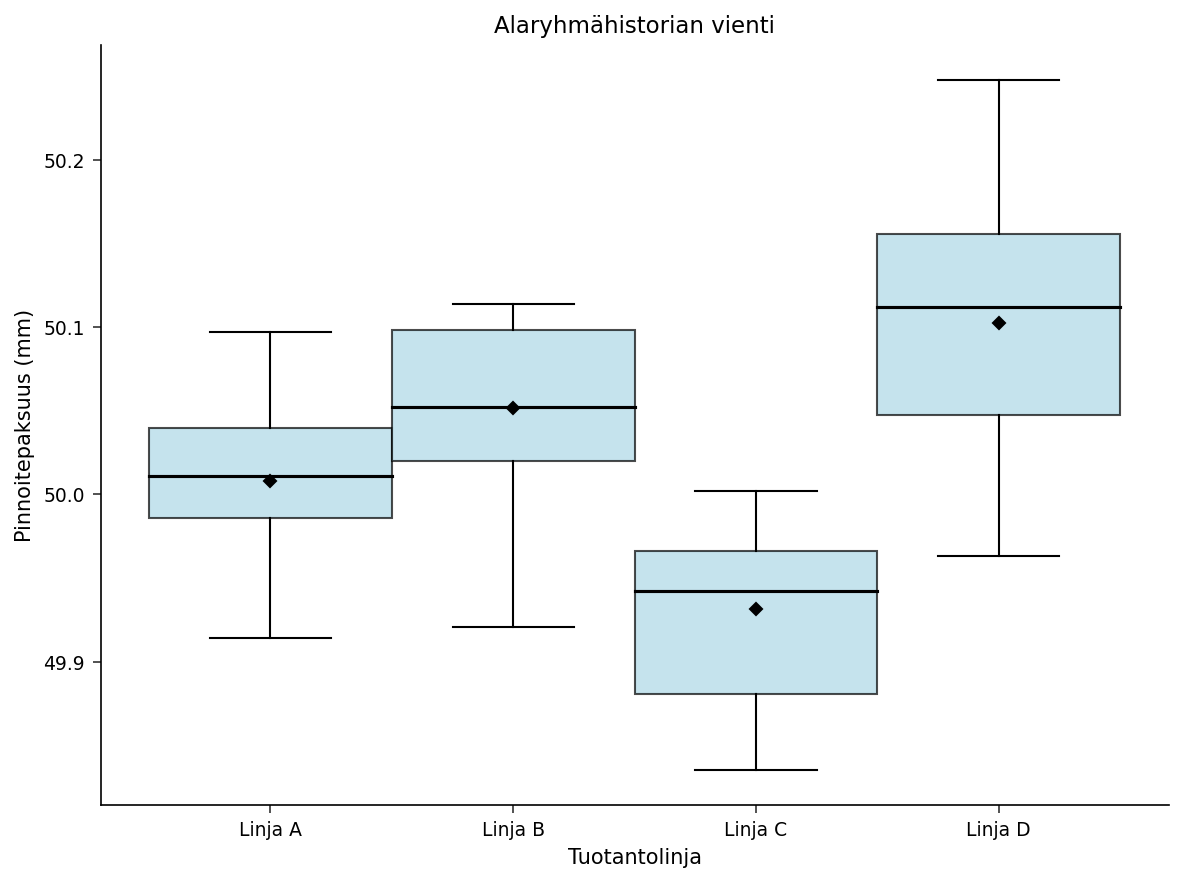

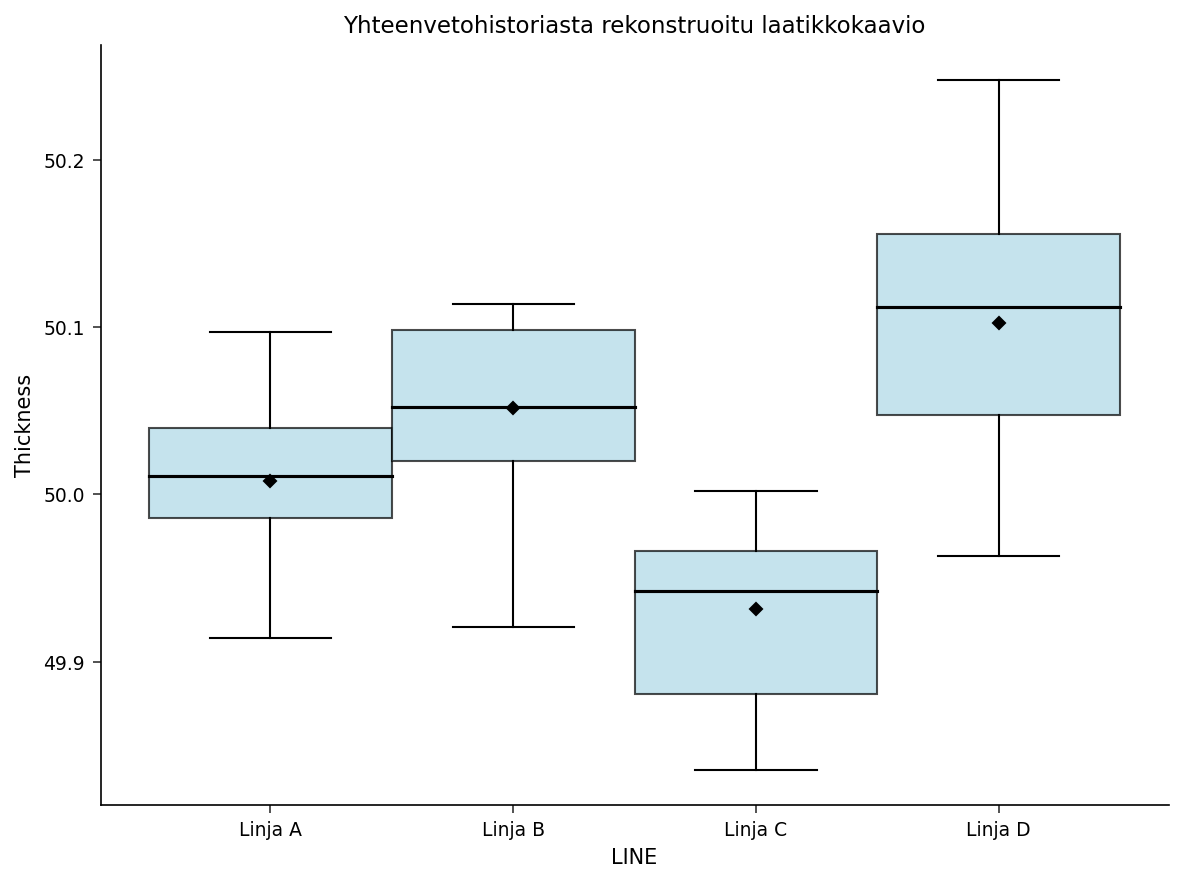

In [6]:
OTSIKKO 'Alaryhmähistorian vienti';
PROSEDUURI boxplot TIEDOT=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
SUORITA;

OTSIKKO 'Yhteenvetohistoria-aineisto (yksi rivi per linja)';
PROSEDUURI TULOSTA TIEDOT=LineHistory noobs;
SUORITA;

OTSIKKO 'Yhteenvetohistoriasta rekonstruoitu laatikkokaavio';
PROSEDUURI boxplot history=LineHistory;
   PLOT Thickness*Line;
SUORITA;

## Tulosten tulkinta

Lukemalla laatikkokaavioita yhdessä `PROC MEANS` -profiilin, `OUTBOX=` -taulukon ja spesifikaatioraja-arvion kanssa:

- **Keskitys.** `LINE-A` on parhaiten keskitetty 50,00 mm:n tavoitteeseen (keskiarvo 50,008 mm, mediaani 50,011 mm). `LINE-B` kulkee hieman korkealla (keskiarvo 50,052 mm). `LINE-C` kulkee matalalla (keskiarvo 49,932 mm, mediaani 49,942 mm), linja ajautuu kohti LSL:ää. `LINE-D` kulkee korkealla (keskiarvo 50,102 mm, mediaani 50,112 mm), linja on lähimpänä USL:ää.
- **Hajonta.** `LINE-D` näyttää leveimmän laatikon ja pisimmät viikset — sen keskihajonta 0,080 mm on noin 60–80 % suurempi kuin muilla kolmella linjalla (0,045–0,051 mm), merkiten sen vähiten vakaaksi linjaksi ja parhaaksi ehdokkaaksi vaihtelun vähentämistutkimukselle. `LINE-A` on tiukin (keskihajonta 0,045 mm).
- **Hännät.** Kaaviotyylissä yksikään linja ei tuota aidattua poikkeamaa: jokainen viiksi yltää linjansa todelliseen minimiin/maksimiin, joten prosessi ei tuota yksittäisiä äärimmäisiä osia. Hajontaerot johtuvat kunkin jakauman pääosasta, ei hajapisteistä.
- **Spesifikaation vaatimustenmukaisuus.** `OUTBOX=` -viiksien päätepisteet, arvioituna 49,80 / 50,20 mm:ää vasten, asettavat linjat `LINE-A`, `LINE-B` ja `LINE-C` täysin **spesifikaation sisään**. `LINE-D` on poikkeus: sen korkea viiksi yltää **50,248 mm:iin**, ohi **50,20 mm:n USL:n** — korkeat osat linjalla `LINE-D` ylittävät ylemmän spesifikaation.
- **Operationalisointi.** `OUTBOX=` -aineisto antaa auditoijille tarkat kvartiilit, viiksien päätepisteet, keskiarvon ja keskihajonnan kuvan takana, ja `OUTHISTORY=` tarjoaa tiiviin, uudelleenpiirrettävän yhden rivin linjaa kohti -yhteenvedon (Vaihe 6), joten kaavio voidaan luoda uudelleen aikataulun mukaan säilyttämättä raakamittauksia — yhteenvedosta uudelleenrakennettu laatikkokaavio on identtinen raakadatasta piirretyn kanssa.

**Toimenpide-ehdotukset:** priorisoi `LINE-D` — sekä keskitä se uudelleen alaspäin kohti tavoitetta että käynnistä vaihtelun vähentämistutkimus vetääksesi sen korkea viiksi takaisin USL:n sisään; nostele `LINE-C`:tä ylöspäin kohti tavoitetta ennen kuin sen matala häntä yltää LSL:ään; `LINE-A` ja `LINE-B` toimivat hyväksyttävästi.